In [27]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3
plt.rcParams["legend.fontsize"] = 10

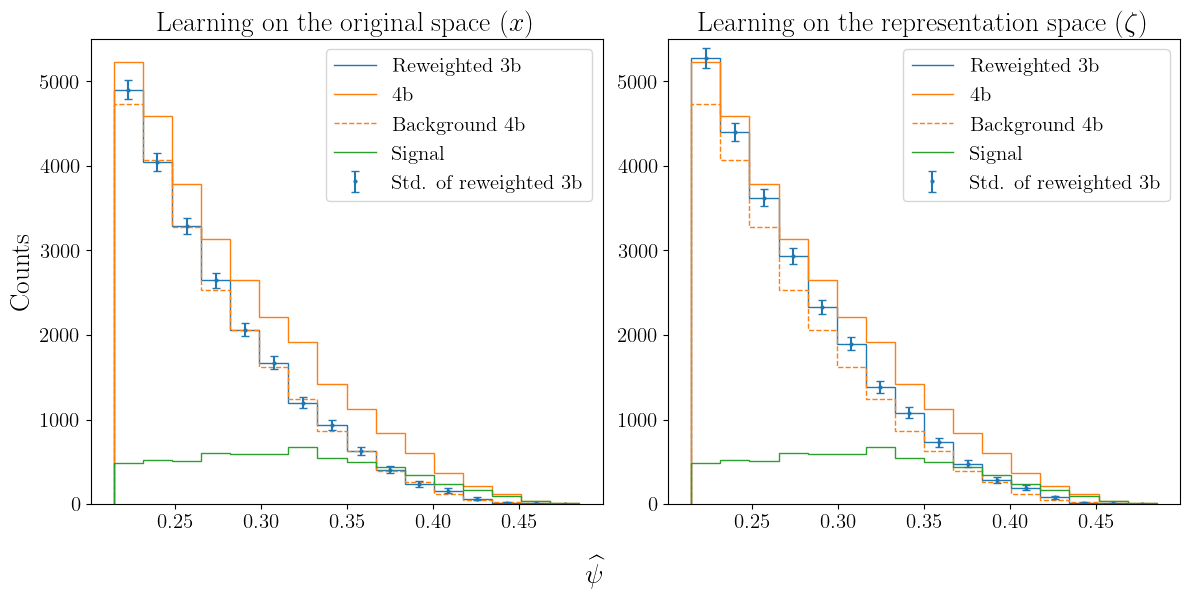

In [39]:
from signal_region import get_SR_CR_cut, get_DRs
import pandas as pd
from utils import get_quantiles_with_weights

plt.rcParams["legend.fontsize"] = 15
plt.rcParams["figure.titlesize"] = 25
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 20
# increase tick label size
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15

n_3b = 100_0000
device = torch.device("cuda")
experiment_name = "CR_fvt_training_v2"
signal_filename = "HH4b_picoAOD.h5"
ratio_4b = 0.5
nbins = 16
signal_ratio = 0.02
seed = 1
CR_fvt_type = ["repr", "original"]

hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: all([x["seed"] == seed, 
                        x["n_3b"] == n_3b, 
                        x["signal_ratio"] == signal_ratio]),
    "aux_info_step": 3
}
hashes = TrainingInfo.find(hparam_filter)
assert len(hashes) == 2

CR_fvt_tinfos = [TrainingInfo.load(hash) for hash in hashes]
for tinfo in CR_fvt_tinfos:
    if tinfo.hparams["model"] == "AttentionClassifier":
        CR_repr_fvt_tinfo = tinfo
    elif tinfo.hparams["model"] == "FvTClassifier":
        CR_orig_fvt_tinfo = tinfo

assert CR_repr_fvt_tinfo.hparams["signal_region"] == CR_orig_fvt_tinfo.hparams["signal_region"]
    
smeared_fvt_hash = CR_orig_fvt_tinfo.hparams["smeared_fvt_hash"]
base_encoder_hash = CR_orig_fvt_tinfo.hparams["encoder_hash"]

base_fvt_model = TrainingInfo.load(base_encoder_hash).load_trained_model(
    CR_orig_fvt_tinfo.hparams["encoder_mode"]
)
base_fvt_model.eval()
base_fvt_model.to(torch.device("cuda"))
base_fvt_model: FvTClassifier

smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)
smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
    CR_orig_fvt_tinfo.hparams["encoder_mode"]
)
smeared_fvt_model.eval()
smeared_fvt_model.to(torch.device("cuda"))

# Use the same mother samples and exclude ones used for training base & smeared FvT model
msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
events_tst = events_from_scdinfo(tst_scdinfo, features, signal_filename)
events_train = events_from_scdinfo(msamples.scdinfo[smeared_fvt_tinfo.ms_idx], features, signal_filename)
SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_orig_fvt_tinfo.hparams["signal_region"])

SR_idx = (SR_stats >= SR_cut)
CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)

events_tst_SR = events_tst[SR_idx]
SR_stats_SR = SR_stats[SR_idx]

events_train_SR = events_train[SR_stats_train >= SR_cut]    
SR_stats_train_SR = SR_stats_train[SR_stats_train >= SR_cut]

q_repr_tst_SR, _ = base_fvt_model.representations(events_tst_SR.X_torch)
q_repr_train_SR, _ = base_fvt_model.representations(events_train_SR.X_torch)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.supxlabel(r"$\widehat{\psi}$")

for ax_cnt, CR_fvt_type in enumerate(["original", "repr"]):
    if ax_cnt == 0:
        ax[ax_cnt].set_ylabel("Counts")
    CR_fvt_tinfo = CR_repr_fvt_tinfo if CR_fvt_type == "repr" else CR_orig_fvt_tinfo
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    CR_fvt_model.to(torch.device("cuda"))
    
    if CR_fvt_type == "repr":
        CR_fvt_model: AttentionClassifier
        fvt_scores_SR = CR_fvt_model.predict(q_repr_tst_SR)[:, 1].detach().cpu().numpy()
        fvt_scores_SR_train = CR_fvt_model.predict(q_repr_train_SR)[:, 1].detach().cpu().numpy()
    else:
        CR_fvt_model: FvTClassifier
        fvt_scores_SR = CR_fvt_model.predict(events_tst_SR.X_torch)[:, 1].detach().cpu().numpy()
        fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
        
    reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
    reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)
    SR_bins = np.linspace(np.min(SR_stats_train_SR), np.max(SR_stats_train_SR), nbins + 1)
    # SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
    #                                     (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
    #                                     np.linspace(0, 1, nbins + 1))
        
    reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
    reweights_SR = np.where(events_tst_SR.is_4b, 1, -reweights_SR)
    
    current_ax = ax[ax_cnt]
    CR_fvt_type_str = r"the representation space ($\zeta$)" if CR_fvt_type == "repr" else r"the original space ($x$)"
    current_ax.set_title(rf"Learning on {CR_fvt_type_str}")
    plot_rewighted_samples_by_model(events_tst_SR, SR_stats_SR, fvt_scores_SR, 
                                    ax=current_ax, bins=SR_bins, disable_twin_ax=True, errorbar="3b")
    hist_bg4b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, 
                                weights=events_tst_SR.weights[events_tst_SR.is_bg4b])
    hist_signal, _ = np.histogram(SR_stats_SR[events_tst_SR.is_signal], bins=SR_bins, 
                                  weights=events_tst_SR.weights[events_tst_SR.is_signal])
    # current_ax.hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, label="3b", histtype="step", linestyle="--", 
                    # weights=events_tst_SR.weights[events_tst_SR.is_3b])
    current_ax.stairs(hist_bg4b, SR_bins, label="Background 4b", color=plt.cm.tab10(1), linestyle="--")
    current_ax.stairs(hist_signal, SR_bins, label="Signal", color=plt.cm.tab10(2))
    current_ax.legend()
    current_ax.set_ylim(bottom=0, top=5500)
    
        
plt.tight_layout()
plt.savefig("./figures/on_which_to_learn.pdf", dpi=300)
plt.show()
plt.close("all")

In [36]:
import pandas as pd

df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

intercept = 0.03912874683737755, slope = 0


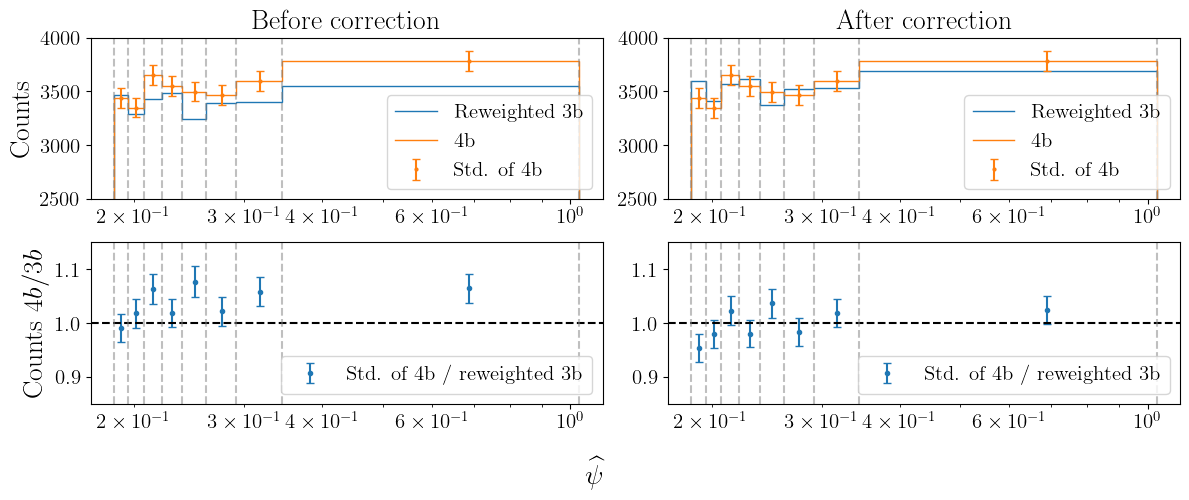

In [38]:
from correct_systematic_error import constrained_linear_fit, get_histograms
from utils import get_quantiles_with_weights
from events_data import get_is_signal
from signal_region import get_SR_CR_cut
from scipy import stats
from plots import plot_samples_raw

slope_min = -0.0
slope_max = 0.0
intercept_min = -np.inf
intercept_max = np.inf
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_v2"
n_3b = 100_0000
nbins = 8

signal_ratio = 0.0
seed = 4

hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3, 
            "model": "FvTClassifier"
        }
hashes = TrainingInfo.find(hparam_filter)
assert len(hashes) == 1

CR_fvt_tinfo = TrainingInfo.load(hashes[0])
base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

base_fvt_model = base_fvt_tinfo.load_trained_model(
    CR_fvt_tinfo.hparams["encoder_mode"]
)
base_fvt_model.eval()
base_fvt_model.to(torch.device("cuda"))
base_fvt_model: FvTClassifier

smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
    CR_fvt_tinfo.hparams["encoder_mode"]
)
smeared_fvt_model.eval()
smeared_fvt_model.to(torch.device("cuda"))
smeared_fvt_model: AttentionClassifier

# Use the same mother samples and exclude ones used for training base & smeared FvT model
msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
events_train = EventsData.from_dataframe(df_train, features)
df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
events_tst = EventsData.from_dataframe(df_tst, features)
SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]

SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])

SR_idx = (SR_stats >= SR_cut)
CR_idx = (SR_stats >= CR_cut) & (SR_stats < SR_cut)

events_train_SR = events_train[(SR_stats_train >= SR_cut)]
SR_stats_train_SR = SR_stats_train[(SR_stats_train >= SR_cut)]

events_tst_SR = events_tst[SR_idx]
SR_stats_SR = SR_stats[SR_idx]

CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
CR_fvt_model.eval()
CR_fvt_model.to(torch.device("cuda"))

CR_fvt_model: FvTClassifier
CR_fvt_scores = CR_fvt_model.predict(events_tst.X_torch)[:, 1].detach().cpu().numpy()
        
fvt_scores_SR = CR_fvt_scores[SR_idx]
reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
reweights_SR = np.where(events_tst_SR.is_4b, 1, reweights_SR)

fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)


SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
                                    (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
                                    np.linspace(0, 1, nbins + 1))

hists = get_histograms(events_tst_SR, SR_stats_SR, SR_bins, reweights_SR)

y = hists["4b"] - hists["3b_rw"]
X = np.stack([hists["3b_rw"], hists["3b_rw_x"]], axis=1)
V = np.diag(hists["3b_sq"] + hists["4b_sq"])

if nbins > 1:
    intercept, slope = constrained_linear_fit(X, y, V,
                                            beta_0_min=intercept_min, beta_0_max=intercept_max,
                                            beta_1_min=slope_min, beta_1_max=slope_max)
else:
    intercept, slope = constrained_linear_fit(X, y, V,
                                            beta_0_min=intercept_min, beta_0_max=intercept_max,
                                            beta_1_min=0, beta_1_max=0)

print(f"intercept = {intercept}, slope = {slope}")

corrected_reweights = reweights_SR * (1 + intercept + slope * SR_stats_SR)
corrected_weights = (
    np.where(events_tst_SR.is_4b, 1, corrected_reweights)
    * events_tst_SR.weights
)

hist_3b_corrected = np.histogram(
    SR_stats_SR[events_tst_SR.is_3b],
    bins=SR_bins,
    weights=corrected_weights[events_tst_SR.is_3b],
)[0]
hist_3b_corrected_sq = np.histogram(
    SR_stats_SR[events_tst_SR.is_3b],
    bins=SR_bins,
    weights=corrected_weights[events_tst_SR.is_3b] ** 2,
)[0]
hists["3b_corrected"] = hist_3b_corrected
hists["3b_corrected_sq"] = hist_3b_corrected_sq

diff_orig = hists["4b"] - hists["3b_rw"]
var_orig = hists["3b_sq"] + hists["4b_sq"]

diff_corrected = hists["4b"] - hists["3b_corrected"]
var_corrected = hists["3b_corrected_sq"] + hists["4b_sq"]

mean_pull_orig = np.sqrt(np.mean(diff_orig**2 / var_orig))
mean_pull_corrected = np.sqrt(np.mean(diff_corrected**2 / var_corrected))

deg_freedom = nbins - 1
chi2_stat_orig = nbins * mean_pull_orig**2
chi2_stat_corrected = nbins * mean_pull_corrected**2
p_value_orig = stats.chi2.sf(chi2_stat_orig, deg_freedom)
p_value_corrected = stats.chi2.sf(chi2_stat_corrected, deg_freedom)

new_weights = events_tst_SR.weights.copy()
new_weights[events_tst_SR.is_3b] = new_weights[events_tst_SR.is_3b] * (
    reweights_SR[events_tst_SR.is_3b] + intercept + slope * SR_stats_SR[events_tst_SR.is_3b])

# SR_plot_bins = np.linspace(SR_stats_SR.min(), SR_stats_SR.max(), 9)
SR_plot_bins = SR_bins
# fig, ax = plt.subplots(1, 2, figsize=(12, 5))


fig = plt.figure(figsize=(12, 5))
gs = GridSpec(2, 2, figure=fig)
# fig.suptitle(f"signal_ratio = {signal_ratio}, seed = {seed}, nbins = {nbins}")
fig.supxlabel(r"$\widehat{\psi}$")

ax_before = fig.add_subplot(gs[0, 0])
ax_after = fig.add_subplot(gs[0, 1])
ax_pull_before = fig.add_subplot(gs[1, 0])
ax_pull_after = fig.add_subplot(gs[1, 1])

ax_before.set_ylabel("Counts")
ax_pull_before.set_ylabel(r"Counts $4b / 3b$")

ax_before.set_title(f"Before correction")
ax_after.set_title(f"After correction")
plot_samples_raw(events_tst_SR.is_4b, reweights_SR * events_tst_SR.weights, SR_stats_SR, ax_before, bins=SR_plot_bins, 
                 disable_twin_ax=True)
hist_3b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_3b], bins=SR_plot_bins, 
                          weights=events_tst_SR.weights[events_tst_SR.is_3b])
hist_bg4b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_plot_bins, 
                          weights=events_tst_SR.weights[events_tst_SR.is_bg4b])
# ax_before.stairs(hist_3b, SR_plot_bins, label="3b", color=plt.cm.tab10(0), linestyle="--")
# ax_before.stairs(hist_bg4b, SR_plot_bins, label="Background 4b", color=plt.cm.tab10(1), linestyle="--")
ax_before.legend()
midpoints = (SR_plot_bins[:-1] + SR_plot_bins[1:]) / 2
ax_pull_before.errorbar(midpoints, 
                        hists["4b"] / hists["3b_rw"],
                        yerr=(1 / hists["3b_rw"]**2) * np.sqrt(hists["3b_rw"]**2 * hists["4b_sq"] + 
                                                               hists["4b"]**2 * hists["3b_sq"]),
                        label="Std. of 4b / reweighted 3b", capsize=3, fmt="o")


plot_samples_raw(events_tst_SR.is_4b, new_weights, SR_stats_SR, ax_after, bins=SR_plot_bins, 
                 disable_twin_ax=True)
hist_3b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_3b], bins=SR_plot_bins, 
                          weights=events_tst_SR.weights[events_tst_SR.is_3b])
hist_bg4b, _ = np.histogram(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_plot_bins, 
                          weights=events_tst_SR.weights[events_tst_SR.is_bg4b])
# ax_after.stairs(hist_3b, SR_plot_bins, label="3b", color=plt.cm.tab10(0), linestyle="--")
# ax_after.stairs(hist_bg4b, SR_plot_bins, label="Background 4b", color=plt.cm.tab10(1), linestyle="--")
ax_after.legend()
ax_pull_after.errorbar(midpoints, 
                        hists["4b"] / hists["3b_corrected"],
                        yerr=(1 / hists["3b_corrected"]**2) * np.sqrt(hists["3b_corrected"]**2 * hists["4b_sq"] + 
                                                               hists["4b"]**2 * hists["3b_corrected_sq"]),
                        label="Std. of 4b / reweighted 3b", capsize=3, fmt="o")


for ax in [ax_pull_before, ax_pull_after]:
    ax.axhline(1, color="black", linestyle="--")
    ax.set_ylim(bottom=0.85, top=1.15)
    
for ax in [ax_before, ax_after]:
    ax.set_ylim(bottom=2500, top=4000)
    
for ax in [ax_before, ax_after, ax_pull_before, ax_pull_after]:
    for bin_edge in SR_bins:
        ax.axvline(bin_edge, color="gray", linestyle="--", alpha=0.5)
    ax.set_xscale("log")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"./figures/systematic_error_correction.pdf", dpi=300)
plt.show()

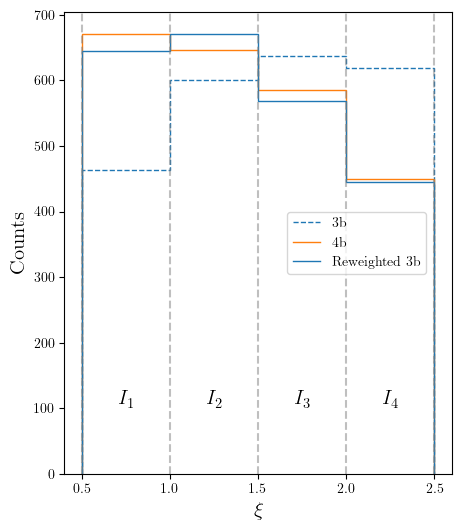

In [94]:
# Counting test example

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

mean_1, sigma_1 = 1, 1.5
mean_2, sigma_2 = 2, 1.5

xi_min = 0.5
xi_max = 2.5

low, high = stats.norm.cdf([xi_min, xi_max], mean_1, sigma_1)
intensity_1 = high - low
low, high = stats.norm.cdf([xi_min, xi_max], mean_2, sigma_2)
intensity_2 = high - low

x1_samples = np.random.normal(mean_1, sigma_1, 5000)
x2_samples = np.random.normal(mean_2, sigma_2, 5000)
pdf1_x2 = stats.norm.pdf(x2_samples, mean_1, sigma_1)
pdf2_x2 = stats.norm.pdf(x2_samples, mean_2, sigma_2) 

x2_reweights = (pdf1_x2 / pdf2_x2) 

bins = np.linspace(xi_min, xi_max, 5)
hist_3b, _ = np.histogram(x2_samples, bins=bins)
hist_3b_rw, _ = np.histogram(x2_samples, bins=bins, weights=x2_reweights)
hist_4b, _ = np.histogram(x1_samples, bins=bins)

plt.rcParams["axes.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 10

fig, ax = plt.subplots(1, 1, figsize=(5, 6))
ax.stairs(hist_3b, bins, label="3b", linestyle="--")
ax.stairs(hist_4b, bins, label="4b")
ax.stairs(hist_3b_rw, bins, label="Reweighted 3b", color=plt.cm.tab10(0))
ax.set_xlabel(r"$\xi$")
ax.set_ylabel("Counts")

for x in bins:
    ax.axvline(x, color="gray", linestyle="--", alpha=0.5)
    
# update the x-axis ticks to bins
ax.set_xticks(bins)
ax.set_xticklabels([f"{x:.1f}" for x in bins])

ax.legend(loc="center right", bbox_to_anchor=(0.95, 0.5))

midpoints = (bins[:-1] + bins[1:]) / 2
for i, x in enumerate(midpoints):
    ax.text(x, 100, rf"$I_{{{i+1}}}$", ha="center", va="bottom", fontsize=15)

# plt.tight_layout()
plt.savefig("./figures/counting_test_toy.pdf", dpi=300)
plt.show()